<a href="https://colab.research.google.com/github/Pratikshapawar-star/python-internship-practice-code/blob/main/images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 ! pip install opendatasets

In [ ]:
import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/techsash/waste-classification-data")

Skipping, found downloaded files in "./waste-classification-data" (use force=True to force download)


Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


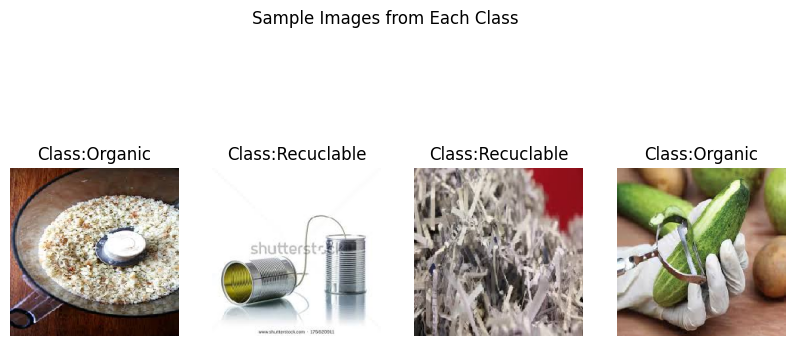

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = '/content/waste-classification-data/DATASET'
train_dir = os.path.join(base_dir, 'TRAIN')
test_dir = os.path.join(base_dir, 'TEST')

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

plt.figure(figsize=(10,5))
for i,(image,label) in enumerate(train_data):
    if i>=4:
        break
    plt.subplot(1,4,i+1)
    plt.imshow(image[0])
    plt.title('Class:'+('Organic'if label[0]==0 else 'Recuclable'))
    plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

In [ ]:
mobilenet_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
mobilenet_model.trainable = False

model = tf.keras.Sequential([
    mobilenet_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)
model.save('mobilenet_waste_classifier.h5')

loss, accuracy = model.evaluate(test_data)
print('Model Accuracy:', accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.8673 - loss: 0.3083 - val_accuracy: 0.8914 - val_loss: 0.2507
Epoch 2/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.9310 - loss: 0.1789 - val_accuracy: 0.8898 - val_loss: 0.2601
Epoch 3/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.9418 - loss: 0.1551 - val_accuracy: 0.8854 - val_loss: 0.2695
Epoch 4/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.9460 - loss: 0.1478 - val_accuracy: 0.9041 - val_loss: 0.2415
Epoch 5/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 55s 77ms/step - accuracy: 0.9451 - loss: 0.1464 - val_accuracy: 0.8957 - val_loss: 0.2618
Epoch 6/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 93s 93ms/step - accuracy: 0.9469 - loss: 0.1404 - val_accuracy: 0.8627 - val_loss: 0.3304
Epoch 7/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 51s 50ms/step - accuracy: 0.9456 - loss: 0.1410 - val_accuracy: 0.8894 - val_loss: 0.2681
Epoch 8/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.9504 - loss: 0.1322 - 

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8981 - loss: 0.2532
Model Accuracy: 0.8945483565330505


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

y_pred_prob=model.predict(test_data).flatten()
y_pred = (y_pred_prob >0.5).astype(int)
y_true= test_data.classes

print('Classification Report:\n', classification_report(y_true,y_pred,target_names=['Organic','Reciclable']))

conf_matrix= confusion_matrix(y_true,y_pred)
print('Confusion Matrix:\n', conf_matrix)


79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step
Classification Report:
               precision    recall  f1-score   support

     Organic       0.55      0.62      0.59      1401
  Reciclable       0.44      0.36      0.40      1112

    accuracy                           0.51      2513
   macro avg       0.49      0.49      0.49      2513
weighted avg       0.50      0.51      0.50      2513

Confusion Matrix:
 [[875 526]
 [707 405]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


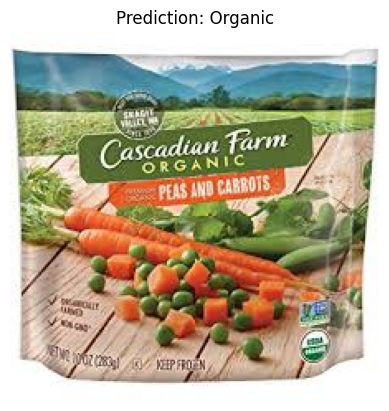

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array


model = tf.keras.models.load_model('mobilenet_waste_classifier.h5')
img = load_img('/content/waste-classification-data/DATASET/TEST/O/O_12578.jpg', target_size=(224, 224))
img_array = np.expand_dims(img_to_array(img)/ 255.0, axis=0)
pred = model.predict(img_array)[0][0]
label = 'Organic' if pred < 0.5 else 'Non Organic'

plt.imshow(img)
plt.title(f'Prediction: {label}')
plt.axis('off')
plt.show()